# Laplacian Matrix Comparison for Community Detection

This notebook compares different types of Laplacian matrices for community detection on the EU Air Transportation Network.

## Laplacian Matrix Types:
1. **Standard Laplacian**: L = D - A
2. **Normalized Laplacian**: L_norm = D^(-1/2) L D^(-1/2)
3. **Random Walk Laplacian**: L_rw = D^(-1) L
4. **Symmetric Normalized Laplacian**: L_sym = I - D^(-1/2) A D^(-1/2)


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import eigsh
from scipy.sparse import diags
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
import collections
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the EU Air Transportation Network
G = nx.Graph()
with open("EU_Air//EUAirTransportation_multiplex.edges", "r") as f:
    for line in f:
        parts = line.strip().split()
        node1, node2, weight = parts[1], parts[2], float(parts[3])
        G.add_edge(node1, node2, weight=weight)

# Load node positions
node_pos = {}
with open("EU_Air//EUAirTransportation_nodes.txt", "r") as f:
    next(f)  # Skip header line
    for line in f:
        parts = line.strip().split()
        node_id = parts[0]
        lon = float(parts[-2])
        lat = float(parts[-1])
        node_pos[node_id] = (lon, lat)

nodes = list(G.nodes())
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_cc = nx.number_connected_components(G)

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Number of connected components: {num_cc}")


Number of nodes: 417
Number of edges: 2953
Number of connected components: 1


In [ ]:

def compute_normalized_laplacian(G, nodes=None):
    """Compute normalized Laplacian: L_norm = D^(-1/2) L D^(-1/2)"""
    if nodes is None:
        nodes = list(G.nodes())
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight="weight", format="csr")
    degrees = np.asarray(A.sum(axis=1)).ravel()
    degrees_safe = degrees.copy()
    degrees_safe[degrees_safe == 0] = 1.0
    D_inv_sqrt = diags(1.0 / np.sqrt(degrees_safe), format="csr")
    L_norm = D_inv_sqrt @ (diags(degrees, format="csr") - A) @ D_inv_sqrt
    return L_norm, degrees

def compute_random_walk_laplacian(G, nodes=None):
    """Compute random walk Laplacian: L_rw = D^(-1) L"""
    if nodes is None:
        nodes = list(G.nodes())
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight="weight", format="csr")
    degrees = np.asarray(A.sum(axis=1)).ravel()
    degrees_safe = degrees.copy()
    degrees_safe[degrees_safe == 0] = 1.0
    D_inv = diags(1.0 / degrees_safe, format="csr")
    L = diags(degrees, format="csr") - A
    L_rw = D_inv @ L
    return L_rw, degrees

def compute_symmetric_normalized_laplacian(G, nodes=None):
    """Compute symmetric normalized Laplacian: L_sym = I - D^(-1/2) A D^(-1/2)"""
    if nodes is None:
        nodes = list(G.nodes())
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight="weight", format="csr")
    degrees = np.asarray(A.sum(axis=1)).ravel()
    degrees_safe = degrees.copy()
    degrees_safe[degrees_safe == 0] = 1.0
    D_inv_sqrt = diags(1.0 / np.sqrt(degrees_safe), format="csr")
    I = diags(np.ones(len(nodes)), format="csr")
    L_sym = I - D_inv_sqrt @ A @ D_inv_sqrt
    return L_sym, degrees

print("Laplacian matrix functions defined successfully!")


Laplacian matrix functions defined successfully!


In [ ]:
# Random Walk Laplacian
L_rw, degrees_rw = compute_random_walk_laplacian(G, nodes)
print("✓ Random Walk Laplacian computed")

# Symmetric Normalized Laplacian
L_sym, degrees_sym = compute_symmetric_normalized_laplacian(G, nodes)
print("✓ Symmetric Normalized Laplacian computed")

print(f"\nAll matrices computed successfully!")
print(f"Matrix dimensions: {L_std.shape}")
print(f"Number of nodes: {len(nodes)}")


Computing different Laplacian matrices...
✓ Standard Laplacian computed
✓ Normalized Laplacian computed
✓ Random Walk Laplacian computed
✓ Symmetric Normalized Laplacian computed

All matrices computed successfully!
Matrix dimensions: (417, 417)
Number of nodes: 417


In [ ]:


def compute_eigenvalues(L, k=50, which='SM'):
    """Compute smallest k eigenvalues"""
    try:
        eigvals, eigvecs = eigsh(L, k=k, which=which)
        perm = np.argsort(eigvals)
        eigvals = eigvals[perm]
        eigvecs = eigvecs[:, perm]
        return eigvals, eigvecs
    except:
        L_dense = L.toarray()
        eigvals, eigvecs = np.linalg.eigh(L_dense)
        perm = np.argsort(eigvals)
        eigvals = eigvals[perm][:k]
        eigvecs = eigvecs[:, perm][:, :k]
        return eigvals, eigvecs


eigvals_rw, eigvecs_rw = compute_eigenvalues(L_rw)
eigvals_sym, eigvecs_sym = compute_eigenvalues(L_sym)




Computing eigenvalues for each Laplacian matrix...
✓ Eigenvalues computed for all Laplacian matrices


In [6]:
# K-selection functions
def pick_k_by_curvature(eigvals, num_cc):
    """Pick K using curvature (second difference) elbow method"""
    lam = np.asarray(eigvals, dtype=float)
    start = int(num_cc)
    tail = lam[start:]
    
    if tail.size < 3:
        gaps = np.diff(tail)
        K = start + (np.argmax(gaps) + 1 if gaps.size else 1)
        return int(K)
    
    second_diff = tail[2:] - 2*tail[1:-1] + tail[:-2]
    elbow_in_tail = int(np.argmax(second_diff)) + 1 
    K = start + elbow_in_tail
    return int(K)

def pick_k_by_gap(eigvals, num_cc):
    """Pick K using largest eigengap method"""
    evals = np.asarray(eigvals, dtype=float)
    if num_cc is None or num_cc <= 0:
        num_cc = int((np.abs(evals) <= 1e-12).sum())
    
    if num_cc >= len(evals) - 1:
        return max(1, num_cc)
    
    tail = evals[num_cc:]
    gaps = np.diff(tail)
    
    if gaps.size == 0:
        return max(1, num_cc)
    
    j = int(np.argmax(gaps))
    K = num_cc + j + 1
    return int(K)

print("K-selection functions defined!")


K-selection functions defined!


In [ ]:

# Random Walk Laplacian
K_rw_curv = pick_k_by_curvature(eigvals_rw, num_cc)
K_rw_gap = pick_k_by_gap(eigvals_rw, num_cc)
print(f"Random Walk Laplacian - K (curvature): {K_rw_curv}, K (gap): {K_rw_gap}")

# Symmetric Normalized Laplacian
K_sym_curv = pick_k_by_curvature(eigvals_sym, num_cc)
K_sym_gap = pick_k_by_gap(eigvals_sym, num_cc)
print(f"Symmetric Normalized Laplacian - K (curvature): {K_sym_curv}, K (gap): {K_sym_gap}")

# Store results
laplacian_results = {
    'Random Walk': {'eigvals': eigvals_rw, 'eigvecs': eigvecs_rw, 'K_curv': K_rw_curv, 'K_gap': K_rw_gap},
    'Symmetric': {'eigvals': eigvals_sym, 'eigvecs': eigvecs_sym, 'K_curv': K_sym_curv, 'K_gap': K_sym_gap}
}


Determining optimal K for each Laplacian matrix...
Standard Laplacian - K (curvature): 4, K (gap): 2
Normalized Laplacian - K (curvature): 7, K (gap): 3
Random Walk Laplacian - K (curvature): 2, K (gap): 3
Symmetric Normalized Laplacian - K (curvature): 7, K (gap): 3


In [ ]:
# Community detection function
def detect_communities(eigvecs, K, nodes, method_name):
    """Detect communities using K-means on normalized eigenvectors"""
    U = eigvecs[:, :K].astype(float, copy=False)
    
    # Normalize rows
    row_norms = np.linalg.norm(U, axis=1, keepdims=True)
    row_norms[row_norms == 0.0] = 1.0
    U_norm = U / row_norms
    
    # K-means clustering
    km = KMeans(n_clusters=K, n_init=20, random_state=0)
    labels = km.fit_predict(U_norm)
    
    # Create community mapping
    community_of = {nodes[i]: int(labels[i]) for i in range(len(nodes))}
    
    return community_of, U_norm

# Plotting function
def plot_communities(G, community_of, node_pos=None, title="Communities on graph",
                     show_labels=False, edge_alpha=0.15, node_size=18):
    """Plot G with nodes colored by community_of[node]."""
    nodes = list(G.nodes())
    
    if node_pos is None:
        pos = nx.spring_layout(G, seed=42)
    else:
        pos = node_pos
    
    nodes_with_pos = [u for u in nodes if u in pos]
    if not nodes_with_pos:
        raise ValueError("No nodes have positions. Provide a valid node_pos.")
    
    labels = np.array([community_of.get(u, -1) for u in nodes_with_pos])
    known_mask = labels >= 0
    unknown_mask = ~known_mask
    
    unique_comms = sorted(np.unique(labels[known_mask]))
    comm_to_idx = {c: i for i, c in enumerate(unique_comms)}
    mapped = np.array([comm_to_idx[c] if c in comm_to_idx else -1 for c in labels])
    
    bright_colors = [
        "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", 
        "#ff7f00", "#ffff33", "#0a0a0a", "#a65628"
    ]
    cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))
    color_list = bright_colors if len(unique_comms) <= len(bright_colors) else cmap.colors
    
    plt.figure(figsize=(10, 8))
    
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v) for u, v in G.edges() if u in pos and v in pos],
        width=0.4, alpha=edge_alpha, edge_color="gray"
    )
    
    xs = [pos[u][0] for u in nodes_with_pos]
    ys = [pos[u][1] for u in nodes_with_pos]
    
    if known_mask.any():
        plt.scatter(
            np.array(xs)[known_mask], np.array(ys)[known_mask],
            c=[color_list[i % len(color_list)] for i in mapped[known_mask]],
            s=node_size, alpha=0.95
        )
    
    if unknown_mask.any():
        plt.scatter(
            np.array(xs)[unknown_mask], np.array(ys)[unknown_mask],
            c="lightgray", s=node_size, alpha=0.9, label="unlabeled"
        )
    
    if show_labels:
        for u in nodes_with_pos:
            x, y = pos[u]
            plt.text(x, y, str(u), fontsize=6, ha="center", va="center")
    
    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=6,
               label=f"c={c}", markerfacecolor=color_list[i % len(color_list)],
               markeredgecolor="none")
        for i, c in enumerate(unique_comms)
    ]
    if unknown_mask.any():
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=6,
                              label="unlabeled", markerfacecolor="lightgray",
                              markeredgecolor="none"))
    if handles:
        plt.legend(handles=handles, title="Communities", loc="best", frameon=True)
    
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



Community detection and plotting functions defined!



--- Standard Laplacian ---


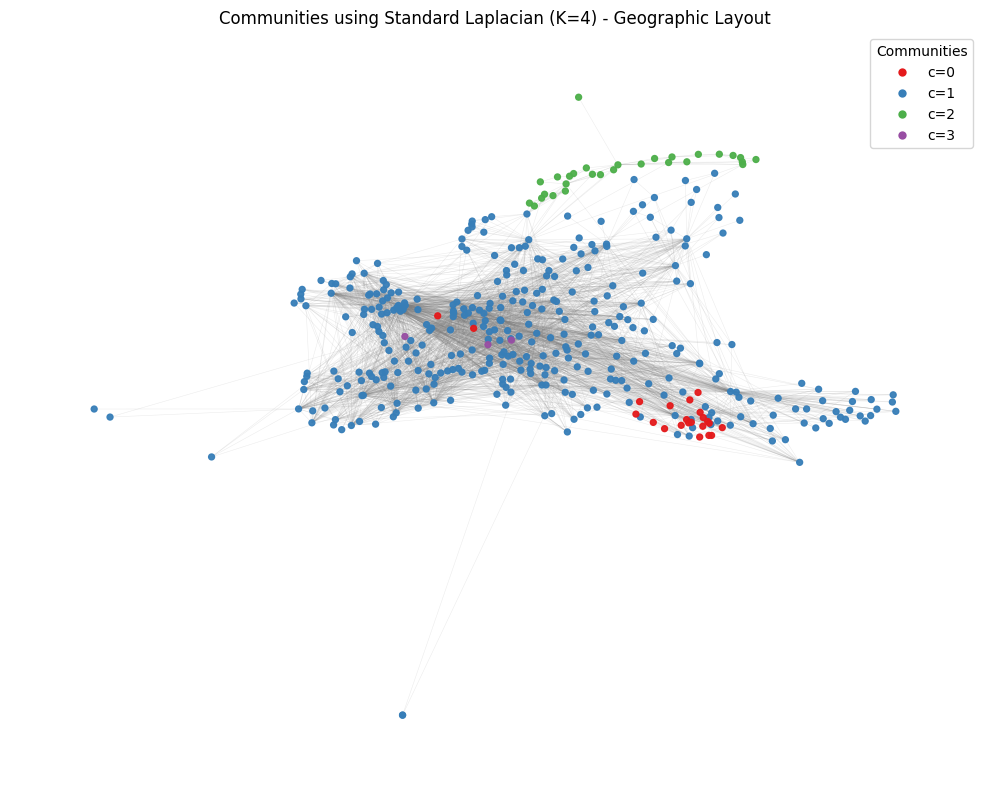


--- Normalized Laplacian ---


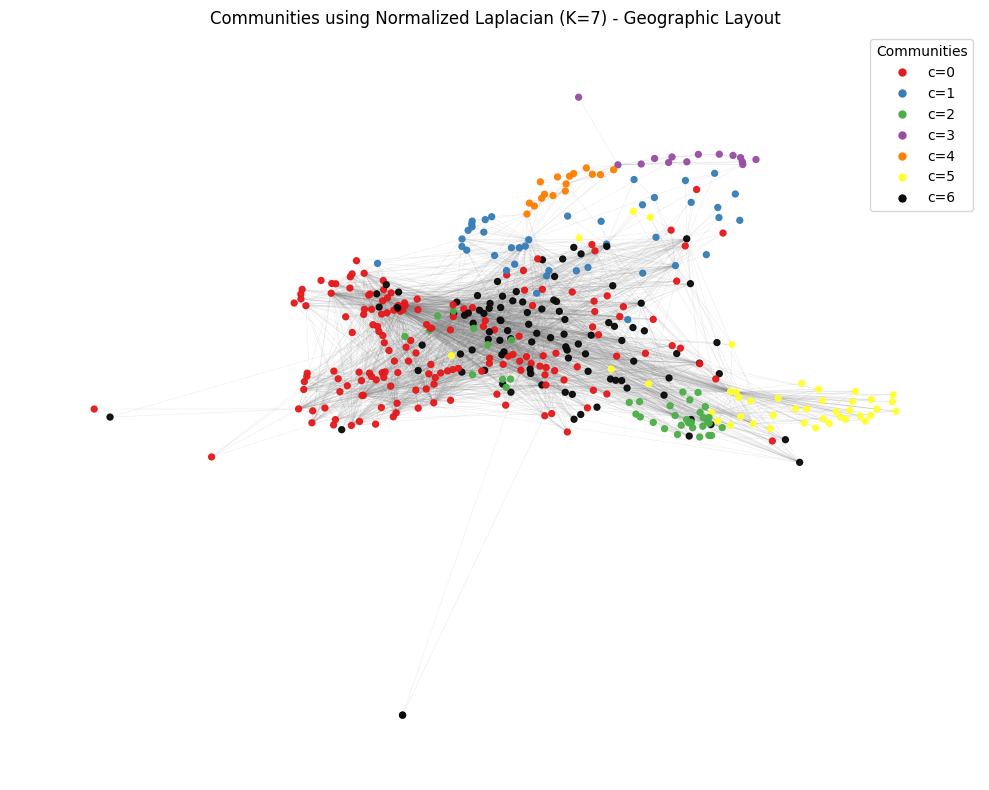


--- Random Walk Laplacian ---


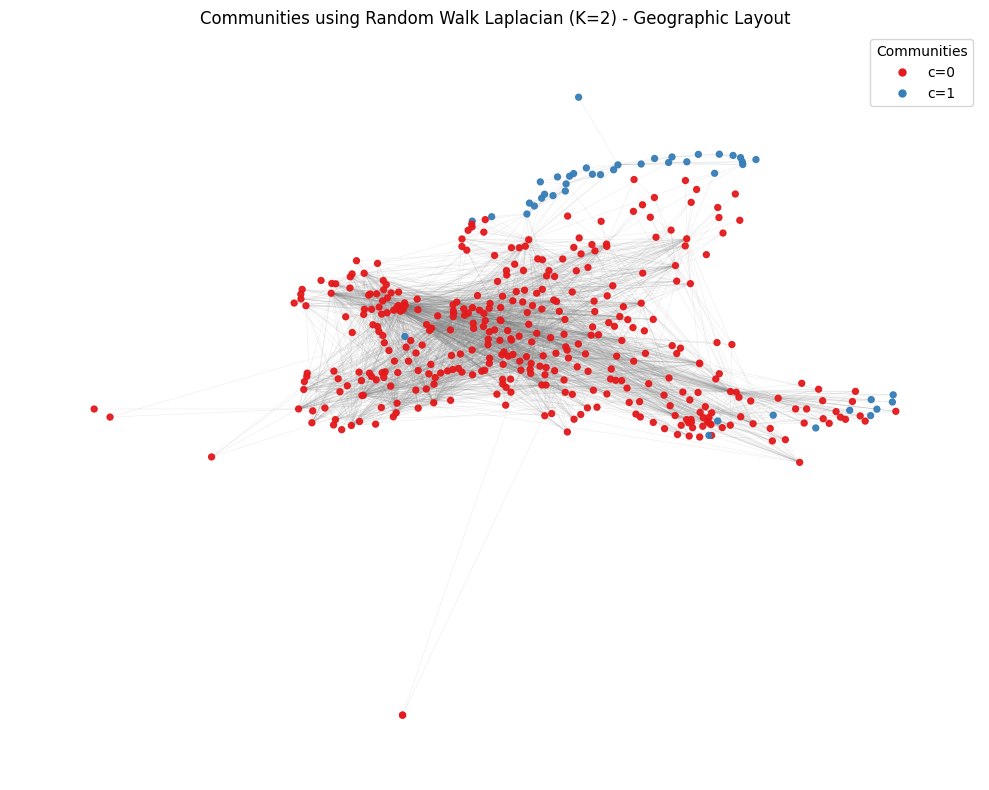


--- Symmetric Laplacian ---


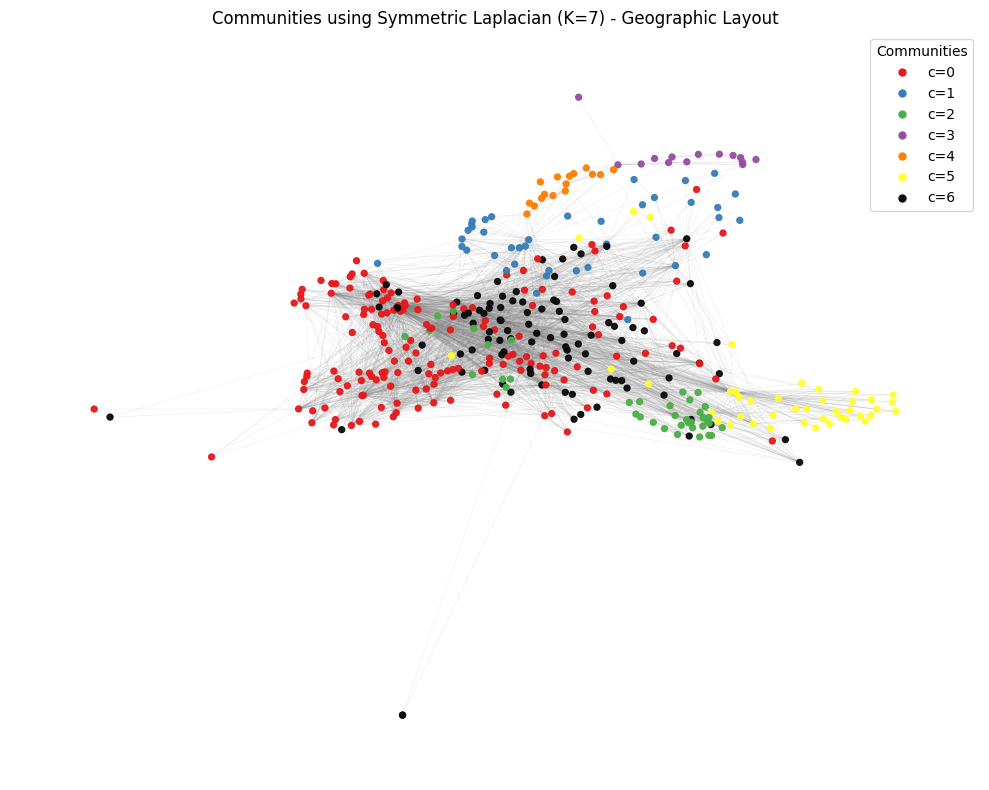

In [20]:

communities_results = {}

for laplacian_name, data in laplacian_results.items():
    print(f"\n--- {laplacian_name} Laplacian ---")
    
    # Use curvature-based K selection
    K = data['K_curv']
    eigvecs = data['eigvecs']
    
    # Detect communities
    community_of, U_norm = detect_communities(eigvecs, K, nodes, laplacian_name)
    
    # Store results
    communities_results[laplacian_name] = {
        'community_of': community_of,
        'K': K,
        'U_norm': U_norm
    }
    
    # Count communities
    unique_communities = len(set(community_of.values()))
    
    # Plot communities using geographic positions
    plot_communities(
        G, community_of, node_pos=node_pos,
        title=f"Communities using {laplacian_name} Laplacian (K={K}) - Geographic Layout",
        show_labels=False
    )



=== SPRING LAYOUT VISUALIZATION ===
This shows how communities look when airports are positioned based on their network connections
rather than their geographic locations. Most connected nodes will be positioned close together.

Computing force-directed layout positions...
✓ Force-directed layout computed


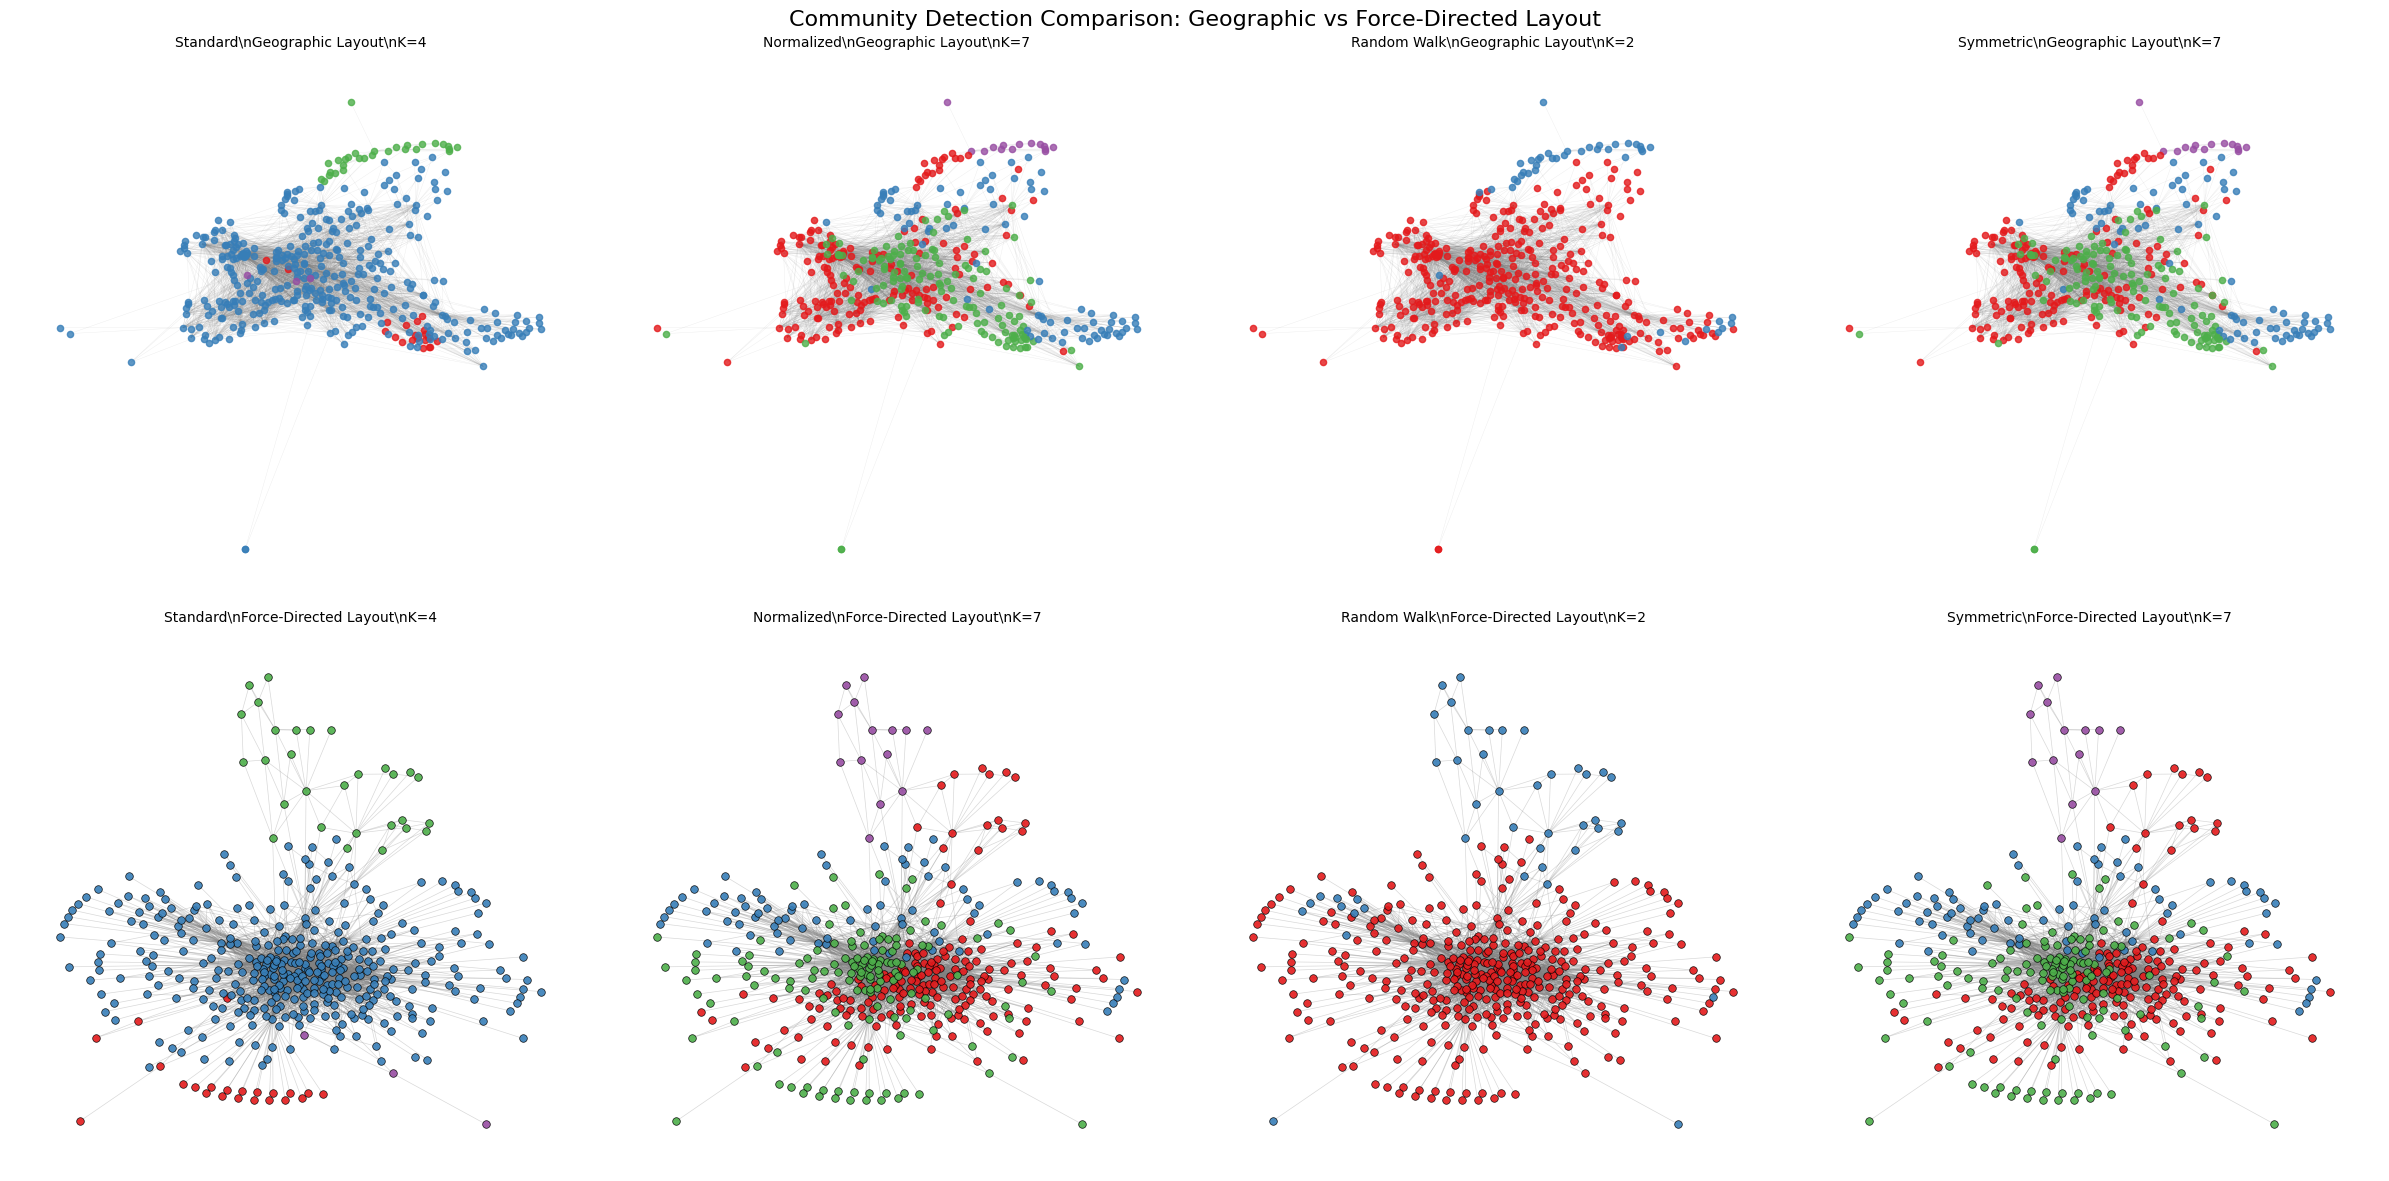

\n=== ANALYSIS ===
The force-directed layout positions nodes based on their connections - most connected
nodes are positioned close together. This reveals true structural communities in the network.

Force-directed layout advantages:
- Better separation of communities
- More stable positioning
- Clearer visualization of network structure
- Optimized for showing community boundaries

Key observations to look for:
- Do communities form tight, well-separated clusters?
- Are highly connected nodes positioned close together?
- Do the communities represent meaningful network structure?
- Which Laplacian matrix produces the clearest community separation?


In [ ]:

force_pos = nx.spring_layout(G, weight='weight', k=0.3, iterations=200, seed=42, scale=2)


# Create side-by-side comparison: Geographic vs Force-Directed Layout
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('Community Detection Comparison: Geographic vs Force-Directed Layout', fontsize=16)

laplacian_names = list(communities_results.keys())
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for idx, (laplacian_name, data) in enumerate(communities_results.items()):
    community_of = data['community_of']
    K = data['K']
    
    # Get unique communities
    unique_comms = sorted(set(community_of.values()))
    
    # Geographic layout (top row)
    ax_geo = axes[0, idx]
    nx.draw_networkx_edges(
        G, node_pos,
        edgelist=[(u, v) for u, v in G.edges() if u in node_pos and v in node_pos],
        width=0.3, alpha=0.15, edge_color="gray", ax=ax_geo
    )
    
    for comm in unique_comms:
        nodes_in_comm = [n for n in G.nodes() if n in node_pos and community_of.get(n) == comm]
        if nodes_in_comm:
            x_coords = [node_pos[n][0] for n in nodes_in_comm]
            y_coords = [node_pos[n][1] for n in nodes_in_comm]
            ax_geo.scatter(x_coords, y_coords, c=colors[comm % len(colors)], 
                          s=20, alpha=0.8, label=f'Community {comm}')
    
    ax_geo.set_title(f'{laplacian_name}\\nGeographic Layout\\nK={K}', fontsize=10)
    ax_geo.axis('off')
    
    # Force-directed layout (bottom row)
    ax_force = axes[1, idx]
    nx.draw_networkx_edges(
        G, force_pos,
        edgelist=[(u, v) for u, v in G.edges() if u in force_pos and v in force_pos],
        width=0.5, alpha=0.3, edge_color="gray", ax=ax_force
    )
    
    for comm in unique_comms:
        nodes_in_comm = [n for n in G.nodes() if n in force_pos and community_of.get(n) == comm]
        if nodes_in_comm:
            x_coords = [force_pos[n][0] for n in nodes_in_comm]
            y_coords = [force_pos[n][1] for n in nodes_in_comm]
            ax_force.scatter(x_coords, y_coords, c=colors[comm % len(colors)], 
                           s=30, alpha=0.9, edgecolors='black', linewidth=0.5, 
                           label=f'Community {comm}')
    
    ax_force.set_title(f'{laplacian_name}\\nForce-Directed Layout\\nK={K}', fontsize=10)
    ax_force.axis('off')
    ax_force.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
